# Lecture 4

## Exercise 1
Consider the function exp(-x^2):
- Integrate this from [-5,5] using integrate.quad.

Consider that you have data that represents a function sampled at N points, but you don't know the analytic form of the function.
Here, we create the sampling from a uniform distribution.
- Compute the integral of this sampled function using Simpson's method (integrate.simps). 
- Vary the number of sample points (try 64, 128, ...) and see how the answer changes. 
- Make a plot of the error (compared to the quadrature result) vs N.

Integrate.quad:
Integral = 1.7724538509027912
Error = 4.626e-14 

Simpson's method:
N =   32	 Integral = 1.7724538507774263	 Error = 1.254e-10
N =   64	 Integral = 1.7724538509012102	 Error = 1.581e-12
N =  128	 Integral = 1.7724538509027423	 Error = 4.885e-14
N =  256	 Integral = 1.7724538509027887	 Error = 2.442e-15
N =  512	 Integral = 1.7724538509027907	 Error = 4.441e-16
N = 1024	 Integral = 1.772453850902791	 Error = 2.220e-16


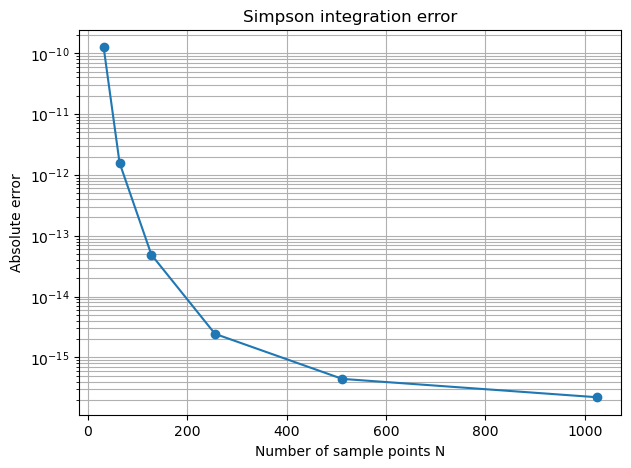

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate


def f(x):
    return np.exp(-x**2)


# Integration with integrate.quad
quad_result, quad_error = integrate.quad(f, -5, 5)

print("Integrate.quad:")
print(f"Integral = {quad_result}")
print(f"Error = {quad_error:.3e} \n")


# Integration with Simpson's method
N_vector = [32, 64, 128, 256, 512, 1024]
errors = []

print("Simpson's method:")

for N in N_vector:

    x = np.linspace(-5, 5, N)
    sample = np.exp(-x**2)

    simpson_result = integrate.simpson(y=sample, x=x)
    error = abs(simpson_result - quad_result)
    errors.append(error)

    print(f"N = {N:4d}\t Integral = {simpson_result}\t Error = {error:.3e}")


# Plot
plt.figure(figsize=(7,5))
plt.plot(N_vector, errors, 'o-')
plt.yscale('log')
plt.xlabel('Number of sample points N')
plt.ylabel('Absolute error')
plt.title('Simpson integration error')
plt.grid(True, 'both')
plt.show()

## Exercise 7
Convolve the noisy data with a Gaussian and plot the result together with the original data. 

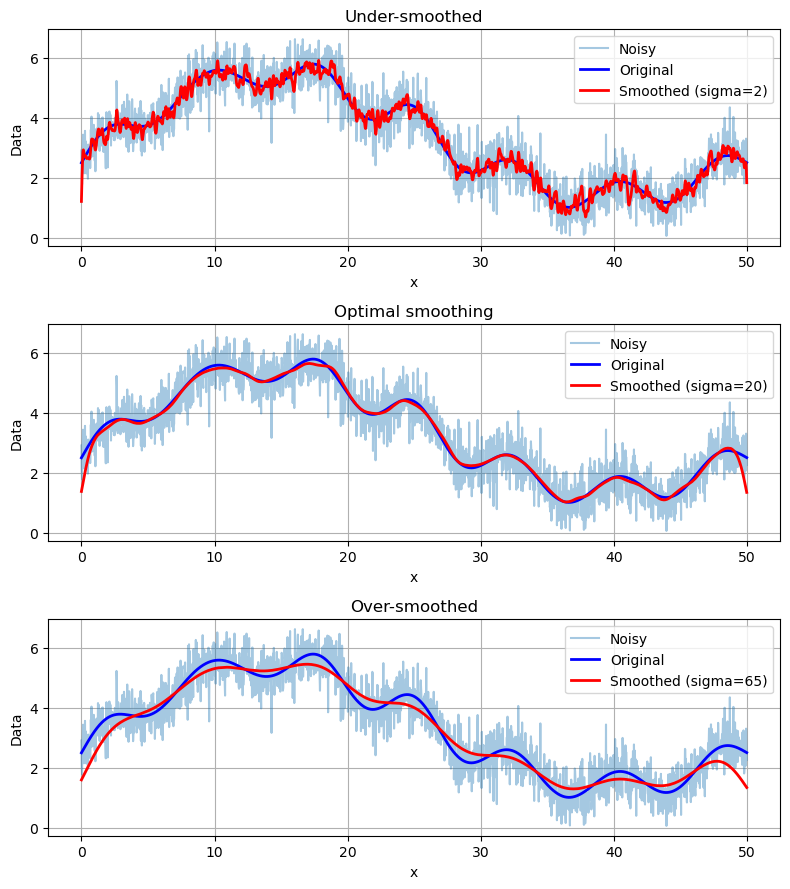

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal


def fdata(x, L):
    
    A = L / 10.0

    return (2*np.sin(2*np.pi*x/L) + x*(L-x)**2 / L**3 * np.cos(x) + 5*x*(L-x)/L**2 + A/2 + 0.1*A*np.sin(13*np.pi*x/L))

# Function for smoothing data with gaussian convolution
def gaussian_smooth(data, sigma):

    window_size = int(5*sigma)
    gauss = signal.windows.gaussian(window_size, sigma)
    gauss /= np.sum(gauss)
    smooth = signal.convolve(data, gauss, mode='same')

    return smooth

# Noisy data
N = 2048
L = 50.0
x = np.linspace(0, L, N, endpoint=False)
orig = fdata(x, L)
noisy = orig + 0.5*np.random.randn(N)

# Smoothing
sigma_1= 2      
sigma_2 = 20      
sigma_3 = 65     
smooth_small = gaussian_smooth(noisy, sigma_1)
smooth_good = gaussian_smooth(noisy, sigma_2)
smooth_large = gaussian_smooth(noisy, sigma_3)

# Plot
fig, axes = plt.subplots(3, 1, figsize=(8,9))

axes[0].plot(x, noisy, alpha=0.4, label='Noisy')
axes[0].plot(x, orig, color='blue', linewidth=2, label='Original')
axes[0].plot(x, smooth_small, color='red', linewidth=2, label=f'Smoothed (sigma={sigma_1})')
axes[0].set_ylabel('Data')
axes[0].set_xlabel('x')
axes[0].set_title('Under-smoothed')
axes[0].legend()
axes[0].grid()

axes[1].plot(x, noisy, alpha=0.4, label='Noisy')
axes[1].plot(x, orig, color='blue', linewidth=2, label='Original')
axes[1].plot(x, smooth_good, color='red', linewidth=2, label=f'Smoothed (sigma={sigma_2})')
axes[1].set_ylabel('Data')
axes[1].set_xlabel('x')
axes[1].set_title('Optimal smoothing')
axes[1].legend()
axes[1].grid()

axes[2].plot(x, noisy, alpha=0.4, label='Noisy')
axes[2].plot(x, orig, color='blue', linewidth=2, label='Original')
axes[2].plot(x, smooth_large, color='red', linewidth=2, label=f'Smoothed (sigma={sigma_3})')
axes[2].set_ylabel('Data')
axes[2].set_xlabel('x')
axes[2].set_title('Over-smoothed')
axes[2].legend()
axes[2].grid()

plt.tight_layout()
plt.show()